In [ ]:
# !pip install jax "jax[cuda13]" optax einops transformers huggingface_hub datasets pynvml

### Setup

Standard imports. `einops` is used for readable tensor reshaping (`rearrange`, `repeat`). `torch` is loaded only once to read the checkpoint — all computation runs in JAX.

## TRM — Tiny Recursive Reasoning Model

A pure-JAX implementation of **TinyRecursiveReasoningModel_ACTV1** from the ARC Prize 2024 verification checkpoint (`arcprize/trm_arc_prize_verification`).

TRM solves tasks by **thinking in loops** — a small 2-layer transformer runs `H_cycles × L_cycles` times per step, updating two latent sequences before outputting predictions. An ACT head signals when to stop.

| Component | Detail |
|---|---|
| **Backbone** | 2-layer L-level transformer (attention + SwiGLU) |
| **Recursion** | 3 H-cycles × 4 L-cycles per inference step, up to 16 steps |
| **Latent state** | `z_H` (high-level "thought") and `z_L` (low-level processing) |
| **Puzzle context** | 16-position prefix from a learned per-task embedding |
| **Checkpoint** | `arcprize/trm_arc_prize_verification` @ `step_518071` |

In [215]:
import os
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'

In [216]:
import glob
import json
import os
from dataclasses import dataclass
from functools import partial
from typing import Optional

import numpy as np
import jax
import jax.numpy as jnp
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
from safetensors.numpy import load_file
from transformers import AutoFeatureExtractor
from einops import rearrange, repeat

In [217]:
jax.devices()

[CpuDevice(id=0)]

In [218]:
import os
os.environ["HF_TOKEN"] = "hf_xxxxxxx"  # Replace with your Hugging Face token

In [ ]:
HF_REPO_ID = "arcprize/trm_arc_prize_verification"
LOCAL_DIR_PATH = "models/trm"

In [ ]:
from huggingface_hub import snapshot_download

local_dir = snapshot_download(
    repo_id=HF_REPO_ID,
    local_dir=LOCAL_DIR_PATH,
)

print(f"Downloaded repository path: {local_dir}")

### Checkpoint

The checkpoint is a raw PyTorch `state_dict` saved at training step 518,071. All keys are prefixed with `_orig_mod.model.inner.` (artifact of `torch.compile`). We use `torch.load` once to pull the weights into CPU tensors, then convert everything to JAX arrays.

In [ ]:
import torch
checkpoint_path = os.path.join(LOCAL_DIR_PATH, "/arc_v1_public/step_518071")
hf_weights = torch.load(checkpoint_path, map_location="cpu")

In [221]:
hf_weights.keys()

odict_keys(['_orig_mod.model.inner.H_init', '_orig_mod.model.inner.L_init', '_orig_mod.model.inner.embed_tokens.embedding_weight', '_orig_mod.model.inner.lm_head.weight', '_orig_mod.model.inner.q_head.weight', '_orig_mod.model.inner.q_head.bias', '_orig_mod.model.inner.puzzle_emb.weights', '_orig_mod.model.inner.L_level.layers.0.self_attn.qkv_proj.weight', '_orig_mod.model.inner.L_level.layers.0.self_attn.o_proj.weight', '_orig_mod.model.inner.L_level.layers.0.mlp.gate_up_proj.weight', '_orig_mod.model.inner.L_level.layers.0.mlp.down_proj.weight', '_orig_mod.model.inner.L_level.layers.1.self_attn.qkv_proj.weight', '_orig_mod.model.inner.L_level.layers.1.self_attn.o_proj.weight', '_orig_mod.model.inner.L_level.layers.1.mlp.gate_up_proj.weight', '_orig_mod.model.inner.L_level.layers.1.mlp.down_proj.weight'])

### Puzzle

> ⚠️ **Disclaimer — demo only, not a real puzzle**
>
> This notebook loads the **ARC v1 weights** from the HuggingFace checkpoint (`arcprize/trm_arc_prize_verification`). To run the model on a *real* ARC task correctly, you need to:
>
> 1. Clone the official [Samsung ARC repository](https://github.com/arcprize/arc-agi)
> 2. Use the ARC-AGI dataset from Kaggle (in the repo)
> 3. Run their data-processing pipeline — it produces inputs and outputs in the exact token format this model expects
> 4. The pipeline also outputs a **`puzzle_identifier`** (an integer index into the learned `puzzle_emb` table) for each task — without this, the model has no task context and cannot produce meaningful outputs
>
> The grid below is a placeholder to verify the forward pass runs end-to-end. All predictions should be treated as noise until a valid `puzzle_identifier` is used.

In [223]:
# ARC v1 puzzle (8×20 grid, values 0-9)
sample_puzzle = [
    [1, 1, 1, 1, 1, 3, 3, 3, 2, 2, 1, 1, 1, 1, 1, 3, 3, 3, 2, 2],
    [1, 1, 1, 1, 1, 3, 3, 3, 2, 2, 1, 1, 1, 1, 1, 3, 3, 3, 2, 2],    
    [3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3],    
    [3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3],    
    [3, 3, 3, 2, 2, 1, 1, 1, 1, 1, 3, 3, 3, 2, 2, 1, 1, 1, 1, 1],
    [3, 3, 3, 2, 2, 1, 1, 1, 1, 1, 3, 3, 3, 2, 2, 1, 1, 1, 1, 1]
]

### Config

All model hyperparameters live in one dataclass. Key values come from `all_config.yaml` in the checkpoint repo.

- `puzzle_emb_len=16` — the 512-dim puzzle embedding is split into 16 prefix positions of 32-dim each (but note `hidden_size=512`, so each position holds the full embedding: `16 × 512 = 8192 >> 512`, meaning most of the prefix is padding — this is by design)
- `H_layers=0` — there is no separate H-level transformer in this checkpoint; `z_H` is updated by `L_level` directly
- `total_seq_len` — the full sequence length the transformer sees: 16 prefix positions + 160 grid tokens = 176

In [224]:
@dataclass
class TRMConfig:
    batch_size: int         = 1
    seq_len: int            = 160       # ARC grid: 8×20 = 160 tokens
    vocab_size: int         = 12        # 12 tokens in this checkpoint
    puzzle_emb_ndim: int    = 512       # puzzle embedding dim == hidden_size
    puzzle_emb_len: int     = 16        # 16 prefix positions (from all_config.yaml)
    num_puzzle_identifiers: int = 876406

    # Recursion
    H_cycles: int           = 3
    L_cycles: int           = 4
    H_layers: int           = 0
    L_layers: int           = 2

    # Transformer
    hidden_size: int        = 512
    num_heads: int          = 8
    expansion: float        = 4.0
    pos_encodings: str      = "rope"
    rms_norm_eps: float     = 1e-5
    rope_theta: float       = 10000.0

    # ACT halting
    halt_max_steps: int     = 16
    halt_exploration_prob: float = 0.1
    no_ACT_continue: bool   = True

    forward_dtype: str      = "bfloat16"

    @property
    def total_seq_len(self):
        """Full sequence length fed into the model: puzzle prefix + tokens."""
        return self.puzzle_emb_len + self.seq_len

config = TRMConfig()


In [225]:
from typing import NamedTuple

class InnerCarry(NamedTuple):
    z_H: jnp.ndarray   # [B, L, D]  high-level latent ("thought")
    z_L: jnp.ndarray   # [B, L, D]  low-level latent


### Weight Loading

The checkpoint is a PyTorch `state_dict`. We convert it to nested Python dicts of JAX arrays.

A few quirks to handle:
- PyTorch weight matrices are `[out, in]` — we transpose to `[in, out]` for `jnp.dot`
- `qkv_proj.weight` is a single fused `[D, 3D]` matrix — split into `q / k / v`
- `gate_up_proj.weight` is fused `[D, 2×intermediate]` — split into `gate / up`
- Embedding tables (`embed_tokens`, `puzzle_emb`) must **not** be transposed — they are indexed by integer IDs

In [226]:
import math

p = '_orig_mod.model.inner.'

def t(
    x: torch.Tensor,
) -> jnp.ndarray:
    a = jnp.array(x.float().numpy())
    return a.T if a.ndim == 2 else a

def linear(
    key: str,
) -> dict:
    d = {'weight': t(hf_weights[key + '.weight'])}
    if key + '.bias' in hf_weights:
        d['bias'] = t(hf_weights[key + '.bias'])
    return d

def attn(
    base: str,
) -> dict:
    qkv = t(hf_weights[base + '.qkv_proj.weight'])  # [D, 3D]
    q, k, v = jnp.split(qkv, 3, axis=-1)
    return {
        'q_proj': {'weight': q},
        'k_proj': {'weight': k},
        'v_proj': {'weight': v},
        'o_proj': linear(base + '.o_proj'),
    }

def mlp(
    base: str,
) -> dict:
    gu = t(hf_weights[base + '.gate_up_proj.weight'])  # [D, 2*intermediate]
    gate, up = jnp.split(gu, 2, axis=-1)
    return {
        'gate_proj': {'weight': gate},
        'up_proj':   {'weight': up},
        'down_proj': linear(base + '.down_proj'),
    }

def extract_params(
    cfg: TRMConfig,
) -> dict:
    params = {
        'embed_scale':  math.sqrt(cfg.hidden_size),
        'embed_tokens': jnp.array(hf_weights[p + 'embed_tokens.embedding_weight'].float().numpy()),
        'puzzle_emb':   jnp.array(hf_weights[p + 'puzzle_emb.weights'].float().numpy()),
        'lm_head':      linear(p + 'lm_head'),
        'q_head':       linear(p + 'q_head'),
        'H_init':       t(hf_weights[p + 'H_init']),
        'L_init':       t(hf_weights[p + 'L_init']),
        'L_level': {'layers': [
            {'self_attn': attn(p + f'L_level.layers.{i}.self_attn'),
             'mlp':       mlp( p + f'L_level.layers.{i}.mlp')}
            for i in range(cfg.L_layers)
        ]},
    }
    print(f"Loaded {cfg.L_layers} layers, hidden_size={cfg.hidden_size}")
    return params


### Token Encoding

ARC grid values (0–9) are used directly as token IDs. The grid is flattened row-by-row into a 1D sequence of length `H × W`.

In [227]:
def puzzle_to_tokens(
    grid: list,
) -> jnp.ndarray:  # [1, H*W]
    flat = np.array(grid, dtype=np.int32).flatten()
    return jnp.array(flat, dtype=jnp.int32)[None, :]

H, W      = len(sample_puzzle), len(sample_puzzle[0])
raw_board = puzzle_to_tokens(sample_puzzle)[0]
tokens    = puzzle_to_tokens(sample_puzzle)

print(f"Grid: {H}×{W} = {H*W} tokens")
print("Input tokens shape:", tokens.shape)
print("First row:", tokens[0, :W].tolist())


Grid: 8×20 = 160 tokens
Input tokens shape: (1, 160)
First row: [1, 1, 1, 1, 1, 3, 3, 3, 2, 2, 1, 1, 1, 1, 1, 3, 3, 3, 2, 2]


### Layers

The three building blocks used throughout the model:

**RoPE** — Rotary Position Embeddings encode position by rotating query/key vectors. `rotate_half` implements the standard half-rotation convention: split the last dimension in two, negate and swap.

**Linear** — a simple `x @ W + b` with weight cast to the input dtype at runtime (keeps params in float32 and computes in bfloat16).

**SwiGLU** — the gated MLP variant: `down(silu(gate(x)) * up(x))`. More expressive than a plain FFN; used in LLaMA and most modern transformers.

In [ ]:
def rotate_half(
    x: jnp.ndarray,  # [..., dim]
) -> jnp.ndarray:    # [..., dim]
    x1, x2 = jnp.split(x, 2, axis=-1)
    return jnp.concatenate([-x2, x1], axis=-1)

def rotary_embedding(
    dim:     int,
    seq_len: int,
    base:    float = 10000.0,
) -> tuple:  # (cos [seq_len, dim], sin [seq_len, dim])
    inv_freq = 1.0 / (base ** (jnp.arange(0, dim, 2, dtype=jnp.float32) / dim))
    t        = jnp.arange(seq_len, dtype=jnp.float32)
    freqs    = jnp.outer(t, inv_freq)
    cos      = jnp.concatenate([jnp.cos(freqs), jnp.cos(freqs)], axis=-1)
    sin      = jnp.concatenate([jnp.sin(freqs), jnp.sin(freqs)], axis=-1)
    return cos, sin

def apply_rotary_pos_emb(
    q:   jnp.ndarray,  # [B, H, L, head_dim]
    k:   jnp.ndarray,  # [B, H, L, head_dim]
    cos: jnp.ndarray,  # [L, head_dim]
    sin: jnp.ndarray,  # [L, head_dim]
) -> tuple:            # (q_rot [B,H,L,head_dim], k_rot [B,H,L,head_dim])
    for _ in range(q.ndim - 2):
        cos = jnp.expand_dims(cos, axis=0)
        sin = jnp.expand_dims(sin, axis=0)
    return (q * cos) + (rotate_half(q) * sin), (k * cos) + (rotate_half(k) * sin)

def casted_linear_forward(
    params: dict,
    x:      jnp.ndarray,    # [..., in_features]
) -> jnp.ndarray:           # [..., out_features]
    w = jnp.asarray(params['weight']).astype(x.dtype)
    y = jnp.dot(x, w)
    if params.get('bias') is not None:
        y = y + jnp.asarray(params['bias']).astype(x.dtype)
    return y


In [ ]:
def rms_norm(
    x:   jnp.ndarray,   # [..., D]
    eps: float = 1e-5,
) -> jnp.ndarray:       # [..., D]
    return x * jax.lax.rsqrt(jnp.mean(x ** 2, axis=-1, keepdims=True) + eps)

def attention_forward(
    params:    dict,
    x:         jnp.ndarray,  # [B, L, D]
    cos:       jnp.ndarray,  # [L, head_dim]
    sin:       jnp.ndarray,  # [L, head_dim]
    num_heads: int,
) -> jnp.ndarray:            # [B, L, D]
    
    B, L, D  = x.shape
    head_dim = D // num_heads
    q = casted_linear_forward(params['q_proj'], x)
    k = casted_linear_forward(params['k_proj'], x)
    v = casted_linear_forward(params['v_proj'], x)

    q = rearrange(q, 'b l (h d) -> b h l d', h=num_heads)
    k = rearrange(k, 'b l (h d) -> b h l d', h=num_heads)
    v = rearrange(v, 'b l (h d) -> b h l d', h=num_heads)
    
    q, k   = apply_rotary_pos_emb(q, k, cos, sin)
    scale  = jnp.sqrt(jnp.array(head_dim, dtype=jnp.bfloat16))
    
    attn_w = jnp.einsum('bhid,bhjd->bhij', q, k) / scale
    attn_w = jax.nn.softmax(attn_w.astype(jnp.float32), axis=-1).astype(q.dtype)
    
    out    = jnp.einsum('bhij,bhjd->bhid', attn_w, v)
    out    = rearrange(out, 'b h l d -> b l (h d)')
    
    return casted_linear_forward(params['o_proj'], out)

def swiglu_forward(
    params: dict,
    x:      jnp.ndarray,    # [B, L, D]
) -> jnp.ndarray:           # [B, L, D]
    gate = casted_linear_forward(params['gate_proj'], x)
    up   = casted_linear_forward(params['up_proj'],   x)
    return casted_linear_forward(params['down_proj'], jax.nn.silu(gate) * up)


### Block & Reasoning Module

Each **transformer block** follows a post-norm pattern: residual add first, then RMS norm, for both attention and MLP sub-layers. There is no causal mask — every token attends to every other token bidirectionally.

The **reasoning module** wraps a stack of blocks and adds an `input_injection` signal before the first block. This is how the input embedding is injected into the latent state at every recursive step — not just at the start.

In [ ]:
def block_forward(
    params: dict,
    x:      jnp.ndarray,  # [B, L, D]
    cos:    jnp.ndarray,  # [L, head_dim]
    sin:    jnp.ndarray,  # [L, head_dim]
    cfg:    TRMConfig,
) -> jnp.ndarray:          # [B, L, D]
    
    attn_out = attention_forward(params['self_attn'], x, cos, sin, cfg.num_heads)
    x = rms_norm(x + attn_out, eps=cfg.rms_norm_eps)

    swiglu_out = swiglu_forward(params['mlp'], x)
    x = rms_norm(x + swiglu_out, eps=cfg.rms_norm_eps)
    return x

def reasoning_module_forward(
    params:          dict,
    z:               jnp.ndarray,  # [B, L, D]
    input_injection: jnp.ndarray,  # [B, L, D]
    cos:             jnp.ndarray,  # [L, head_dim]
    sin:             jnp.ndarray,  # [L, head_dim]
    cfg:             TRMConfig,
) -> jnp.ndarray:                  # [B, L, D]
    z = z + input_injection
    for layer_params in params['layers']:
        z = block_forward(layer_params, z, cos, sin, cfg)
    return z


### Embeddings & Inner Forward

**`input_embeddings_forward`** builds the full `[B, 16+160, 512]` sequence:
1. Look up token embeddings from `embed_tokens` → `[B, 160, 512]`
2. Look up the per-task puzzle embedding → `[B, 512]`, reshape to `[B, 16, 32]`, pad to `[B, 16, 512]` → 16 prefix tokens
3. Concatenate prefix + tokens, scale by `√hidden_size`

**`inner_forward`** runs one full `H_cycles × L_cycles` pass. The recursion:
- `z_L` is updated by injecting `z_H + input_emb` (low-level reads both the high-level thought and the input)
- `z_H` is then updated by injecting `z_L` (high-level integrates what low-level computed)
- Logits are read from `z_H` positions `[16:]` (i.e. the 160 grid positions, not the prefix)

In [236]:
def input_embeddings_forward(
    params:     dict,
    tokens:     jnp.ndarray,  # [B, seq_len]
    puzzle_ids: jnp.ndarray,  # [B]
    cfg:        TRMConfig,
) -> jnp.ndarray:              # [B, puzzle_emb_len + seq_len, D]
    emb = params['embed_scale'] * params['embed_tokens'][tokens.astype(jnp.int32)]
    if cfg.puzzle_emb_ndim > 0:
        D   = params['H_init'].shape[0]
        pz  = params['puzzle_emb'][puzzle_ids.astype(jnp.int32)]  # [B, ndim]
        pad = cfg.puzzle_emb_len * D - pz.shape[-1]
        if pad > 0:
            pz = jnp.pad(pz, ((0, 0), (0, pad)))
        pz  = pz.reshape(-1, cfg.puzzle_emb_len, D)
        emb = jnp.concatenate([pz, emb], axis=1)
    return emb

def inner_forward(
    params: dict,
    carry:  InnerCarry,
    batch:  dict,
    cfg:    TRMConfig,
) -> tuple:  # (InnerCarry, logits [B, seq_len, vocab], q_out [B, 2])
    D         = params['H_init'].shape[0]
    head_dim  = D // cfg.num_heads
    cos, sin  = rotary_embedding(dim=head_dim, seq_len=cfg.total_seq_len, base=cfg.rope_theta)
    input_emb = input_embeddings_forward(params, batch['inputs'], batch['puzzle_identifiers'], cfg).astype(jnp.bfloat16)

    z_H, z_L = carry.z_H, carry.z_L
    for _ in range(cfg.H_cycles):
        for _ in range(cfg.L_cycles):
            z_L = reasoning_module_forward(params['L_level'], z_L, z_H + input_emb, cos, sin, cfg)
        z_H = reasoning_module_forward(params['L_level'], z_H, z_L, cos, sin, cfg)

    for _ in range(cfg.L_cycles):
        z_L = reasoning_module_forward(params['L_level'], z_L, z_H + input_emb, cos, sin, cfg)
    z_H = reasoning_module_forward(params['L_level'], z_H, z_L, cos, sin, cfg)

    logits = casted_linear_forward(params['lm_head'], z_H[:, cfg.puzzle_emb_len:])
    q_out  = casted_linear_forward(params['q_head'],  z_H[:, 0])
    return InnerCarry(z_H=z_H, z_L=z_L), logits, q_out


### Inference

**`init_carry`** tiles the learned 1D `H_init` / `L_init` vectors to `[B, total_seq_len, D]` — the same starting state is broadcast to every sequence position.

**`trm_inference`** loops `inner_forward` for `halt_max_steps` steps. Following the original implementation, halting is disabled during evaluation — the model always runs all steps. The ACT head (`q_head`) is only used during training to decide when to stop early.

In [237]:
def init_carry(
    params:     dict,
    batch_size: int,
    cfg:        TRMConfig,
) -> InnerCarry:
    L  = cfg.total_seq_len
    H  = repeat(params['H_init'], 'd -> b l d', b=batch_size, l=L)
    L_ = repeat(params['L_init'], 'd -> b l d', b=batch_size, l=L)
    return InnerCarry(
        z_H=jnp.array(H).astype(jnp.bfloat16),
        z_L=jnp.array(L_).astype(jnp.bfloat16),
    )


In [238]:
def trm_inference(
    params:     dict,
    tokens:     jnp.ndarray,  # [B, seq_len]
    puzzle_ids: jnp.ndarray,  # [B]
    cfg:        TRMConfig,
) -> jnp.ndarray:              # [B, seq_len, vocab_size]
    batch = {'inputs': tokens, 'puzzle_identifiers': puzzle_ids}
    carry = init_carry(params, tokens.shape[0], cfg)
    for _ in range(cfg.halt_max_steps):
        carry, logits, _ = inner_forward(params, carry, batch, cfg)
    return logits


### Run

Extract params, run inference, display the predicted output grid.

Since we are using `puzzle_identifier=0` (a zero-initialised embedding slot), the model has no task context — these predictions are not meaningful. Swap in the correct `puzzle_identifier` from the official data pipeline to get real results.

In [239]:
params     = extract_params(config)
puzzle_ids = jnp.zeros((1,), dtype=jnp.int32)
logits     = trm_inference(params, tokens, puzzle_ids, config)

preds = jnp.argmax(logits[0], axis=-1)   # [seq_len]

print("Input grid:")
for row in raw_board.reshape(H, W).tolist():
    print(' '.join(map(str, row)))

print("\nPredicted output grid:")
for row in preds.reshape(H, W).tolist():
    print(' '.join(map(str, row)))


Loaded 2 layers, hidden_size=512
Input grid:
1 1 1 1 1 3 3 3 2 2 1 1 1 1 1 3 3 3 2 2
1 1 1 1 1 3 3 3 2 2 1 1 1 1 1 3 3 3 2 2
3 3 3 3 3 1 1 1 1 1 3 3 3 3 3 1 1 1 1 1
1 1 1 1 1 3 3 3 3 3 1 1 1 1 1 3 3 3 3 3
3 3 3 3 3 1 1 1 1 1 3 3 3 3 3 1 1 1 1 1
1 1 1 1 1 3 3 3 3 3 1 1 1 1 1 3 3 3 3 3
3 3 3 2 2 1 1 1 1 1 3 3 3 2 2 1 1 1 1 1
3 3 3 2 2 1 1 1 1 1 3 3 3 2 2 1 1 1 1 1

Predicted output grid:
1 1 1 1 1 3 2 3 2 2 1 1 1 1 1 3 3 3 2 2
1 1 1 1 1 3 3 3 3 2 1 1 1 1 1 3 3 3 2 2
4 4 4 3 3 1 1 1 1 1 4 3 4 4 4 1 1 1 1 1
1 1 1 1 1 4 4 3 3 3 1 1 4 1 1 3 2 3 3 3
3 3 3 3 3 1 1 1 1 1 2 3 3 3 3 1 1 1 1 1
1 1 1 1 1 3 3 3 3 1 1 1 1 1 1 2 3 3 3 3
1 1 1 2 2 1 1 1 1 1 3 3 3 2 2 1 1 1 1 1
2 3 3 2 2 1 1 1 1 1 3 3 3 2 2 1 1 1 1 1


### Visualisations

Three views that expose TRM's recursive nature — things you can't see in a standard one-pass transformer:

1. **Halt probability over steps** — `sigmoid(q_out[:, 0])` at each `inner_forward` call. Rises as the model "decides" it's done thinking.
2. **Latent drift per step** — `‖z_H[t] − z_H[t−1]‖` per step. Converging to zero means the model's high-level thought has stabilised.
3. **Per-cell prediction confidence** — `max(softmax(logits))` per grid cell. Low-confidence cells are where the model is uncertain about its answer.

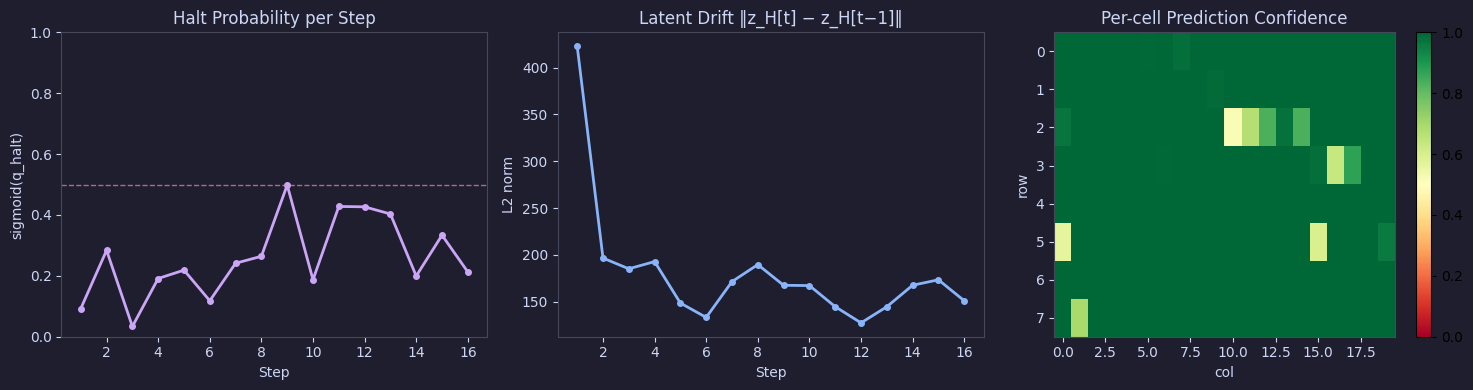

In [240]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

def trm_inference_tracked(
    params:     dict,
    tokens:     jnp.ndarray,  # [B, seq_len]
    puzzle_ids: jnp.ndarray,  # [B]
    cfg:        TRMConfig,
) -> tuple:  # (logits, halt_probs [steps], drifts [steps])
    batch      = {'inputs': tokens, 'puzzle_identifiers': puzzle_ids}
    carry      = init_carry(params, tokens.shape[0], cfg)
    halt_probs = []
    drifts     = []
    prev_z_H   = carry.z_H

    for _ in range(cfg.halt_max_steps):
        carry, logits, q_out = inner_forward(params, carry, batch, cfg)
        halt_probs.append(float(jax.nn.sigmoid(q_out[0, 0])))
        drifts.append(float(jnp.linalg.norm(carry.z_H - prev_z_H)))
        prev_z_H = carry.z_H

    return logits, halt_probs, drifts

logits_v, halt_probs, drifts = trm_inference_tracked(params, tokens, puzzle_ids, config)
steps = list(range(1, config.halt_max_steps + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#1e1e2e')
for ax in axes:
    ax.set_facecolor('#1e1e2e')
    ax.tick_params(colors='#cdd6f4')
    ax.xaxis.label.set_color('#cdd6f4')
    ax.yaxis.label.set_color('#cdd6f4')
    ax.title.set_color('#cdd6f4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#45475a')

# 1. Halt probability
axes[0].plot(steps, halt_probs, color='#cba6f7', linewidth=2, marker='o', markersize=4)
axes[0].axhline(0.5, color='#f38ba8', linestyle='--', linewidth=1, alpha=0.7)
axes[0].set_title('Halt Probability per Step')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('sigmoid(q_halt)')
axes[0].set_ylim(0, 1)

# 2. Latent drift
axes[1].plot(steps, drifts, color='#89b4fa', linewidth=2, marker='o', markersize=4)
axes[1].set_title('Latent Drift ‖z_H[t] − z_H[t−1]‖')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('L2 norm')

# 3. Per-cell confidence
probs      = jax.nn.softmax(logits_v[0].astype(jnp.float32), axis=-1)
confidence = np.array(jnp.max(probs, axis=-1)).reshape(H, W)
im = axes[2].imshow(confidence, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')
axes[2].set_title('Per-cell Prediction Confidence')
axes[2].set_xlabel('col')
axes[2].set_ylabel('row')
plt.colorbar(im, ax=axes[2])

plt.tight_layout()
plt.show()
